# Лабораторная работа №1
## Анализ и прогнозирование временных рядов на примере розничных продаж

Ряд из `retail_sales_mock_data.csv`, помесячные продажи и два флага, была ли акция и праздничный ли это месяц.


In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from scipy.fft import fft, fftfreq
from scipy.signal import detrend, windows
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
import pywt

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")

df = pd.read_csv(
    "retail_sales_mock_data.csv",
    parse_dates=["Date"],
    index_col="Date",
)
df = df.sort_index()
# частота MS, начало месяца, шаг ряда нужен seasonal_decompose
df.index.freq = "MS"

y = df["SalesAmount"].astype(float)

df.head()

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


In [2]:
# до графиков смотрим только дырки и масштаб чисел
print("пропуски")
print(df.isna().sum())
print()
print(f"длина {len(df)}, с {df.index.min().date()} по {df.index.max().date()}")
print()
print(df.describe().round(1))


пропуски
SalesAmount     0
Promotion       0
HolidayMonth    0
dtype: int64

длина 48, с 2020-01-01 по 2023-12-01

       SalesAmount  Promotion  HolidayMonth
count         48.0       48.0          48.0
mean       11768.5        0.1           0.1
std         2257.5        0.3           0.3
min         7783.0        0.0           0.0
25%        10219.8        0.0           0.0
50%        11851.0        0.0           0.0
75%        13014.0        0.0           0.0
max        17996.0        1.0           1.0


48 месяцев, с января 2020 по декабрь 2023, пропусков нет. Четыре полных года, для сезонной модели это мало, но хотя бы период не обрезан посередине.

Средние продажи около 11.8 тысяч, разброс большой, минимум 7783, максимум 17996. `Promotion` стоит в 6 месяцах из 48, `HolidayMonth` только в четырёх декаблях. Праздник тут не отдельный фактор, а подпись к декабрю.


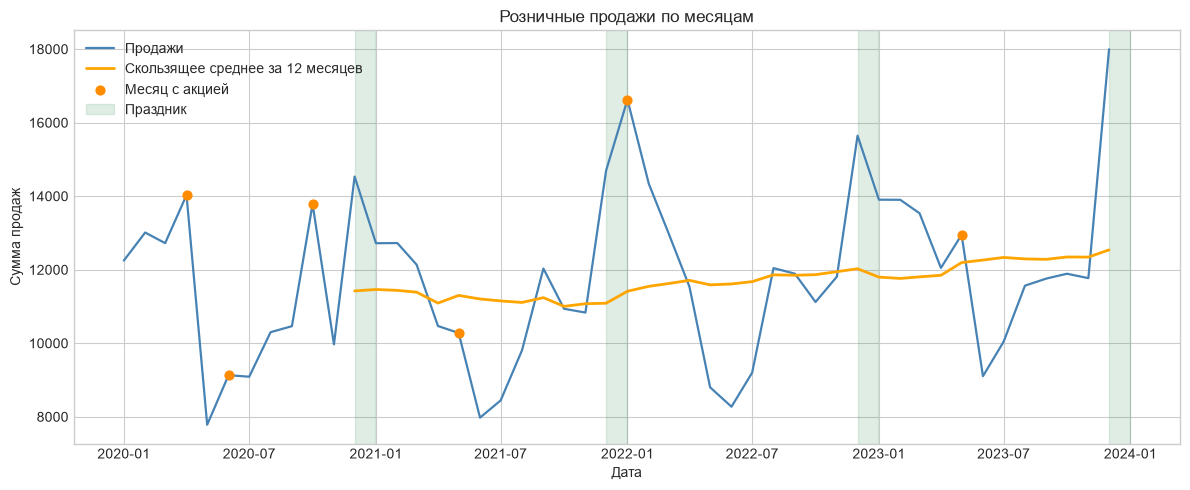

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(y.index, y.values, color="steelblue", linewidth=1.6, label="Продажи")
# 12 месяцев, чтобы сезон не принять за рост
ax.plot(
    y.index,
    y.rolling(window=12).mean(),
    color="orange",
    linewidth=2,
    label="Скользящее среднее за 12 месяцев",
)

# точки акций отдельно, на линии их не разглядеть
promo_idx = df.index[df["Promotion"] == 1]
ax.scatter(
    promo_idx,
    y.loc[promo_idx],
    color="darkorange",
    s=40,
    zorder=4,
    label="Месяц с акцией",
)

# отмечаем месяцы, где в данных стоит праздник
holiday_idx = df.index[df["HolidayMonth"] == 1]
for i, ts in enumerate(holiday_idx):
    ax.axvspan(
        ts,
        ts + pd.offsets.MonthEnd(0),
        color="seagreen",
        alpha=0.15,
        label="Праздник" if i == 0 else None,
    )

ax.set_title("Розничные продажи по месяцам")
ax.set_xlabel("Дата")
ax.set_ylabel("Сумма продаж")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


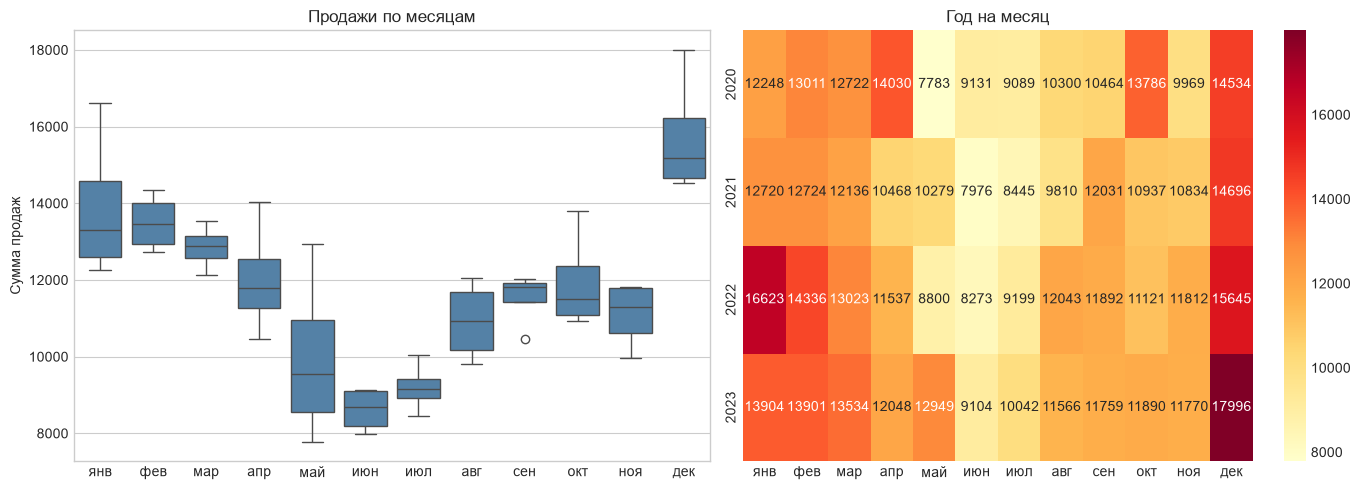

среднее по месяцам
Date
1     13874.0
2     13493.0
3     12854.0
4     12021.0
5      9953.0
6      8621.0
7      9194.0
8     10930.0
9     11536.0
10    11934.0
11    11096.0
12    15718.0

среднее по годам
Date
2020    11422.0
2021    11088.0
2022    12025.0
2023    12539.0


In [4]:
months = ["янв", "фев", "мар", "апр", "май", "июн",
          "июл", "авг", "сен", "окт", "ноя", "дек"]

plot_df = df.copy()
plot_df["month"] = plot_df.index.month
plot_df["year"] = plot_df.index.year

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# на месяц четыре года, смотрим разброс внутри месяца
sns.boxplot(data=plot_df, x="month", y="SalesAmount", ax=axes[0], color="steelblue")
axes[0].set_xticks(range(12))
axes[0].set_xticklabels(months)
axes[0].set_title("Продажи по месяцам")
axes[0].set_xlabel("")
axes[0].set_ylabel("Сумма продаж")

# строки это годы, столбцы месяцы
heat = y.groupby([y.index.year, y.index.month]).mean().unstack()
heat.columns = months
sns.heatmap(heat, annot=True, fmt=".0f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Год на месяц")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print("среднее по месяцам")
print(y.groupby(y.index.month).mean().round(0).to_string())
print()
print("среднее по годам")
print(y.groupby(y.index.year).mean().round(0).to_string())


In [5]:
# средние по акции и по празднику, список месяцев с акцией
print("акция, среднее", round(y[df["Promotion"] == 1].mean(), 0),
      "  месяцев", int(df["Promotion"].sum()))
print("без акции, среднее", round(y[df["Promotion"] == 0].mean(), 0))
print("декабрь, среднее", round(y[df["HolidayMonth"] == 1].mean(), 0))
print("не декабрь, среднее", round(y[df["HolidayMonth"] == 0].mean(), 0))
print()
print("месяцы с акцией")
print(df.index[df["Promotion"] == 1].strftime("%Y-%m").tolist())


акция, среднее 12800.0   месяцев 6
без акции, среднее 11621.0
декабрь, среднее 15718.0
не декабрь, среднее 11410.0

месяцы с акцией
['2020-04', '2020-06', '2020-10', '2021-05', '2022-01', '2023-05']


**Вывод по разведке ряда.** Форма года одна и та же. С мая по июль дно (июнь в среднем 8621), декабрь пик (около 15718). Скользящее среднее за 12 месяцев почти плоское в 2020 и 2021 и чуть поднимается в 2022 и 2023. Это не линейный рост с первого месяца, 2021 даже чуть ниже 2020 (11088 против 11422), потом 12025 и 12539.

Акции стоят вразнобой, апрель, июнь и октябрь 2020, май 2021, январь 2022, май 2023. Голое среднее в эти месяцы выше (12800 против 11621), но часть акций попала как раз на летнее дно, так что тысяча разницы плохо оценивает эффект. Его нормально считать уже внутри модели, когда месяц учтён.

Для прогноза отсюда берём период 12, тренд слабый, декабрь и лето надо уметь повторять. Обычная модель без сезонности это не вытянет.


## Стационарность, ACF и PACF

По графику продаж со скользящим средним за 12 месяцев ряд не похож на случайное блуждание, он болтается вокруг своего уровня. Проверяем тестами и смотрим, на каких лагах есть память. От этого зависят `d`, `p` и `q`.


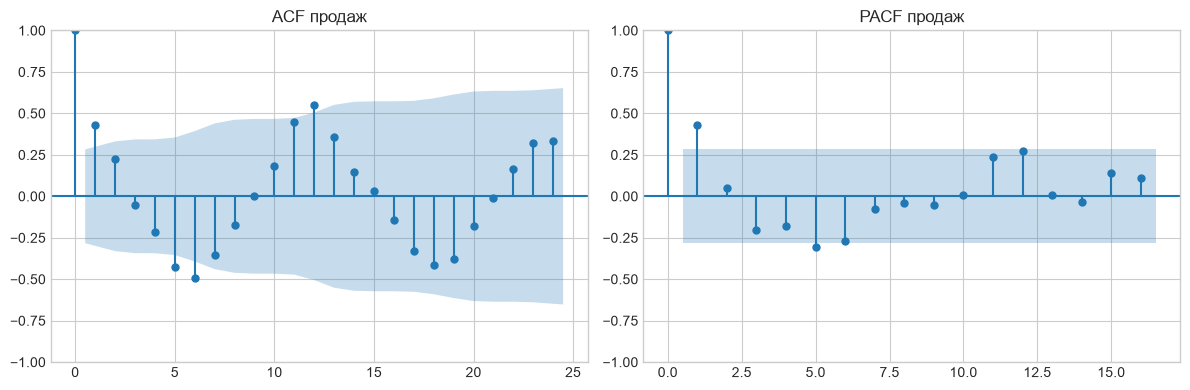

In [6]:
# до 24 лагов, чтобы увидеть короткий хвост, год и два года, дальше на 48 точках уже шум
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(y, lags=24, ax=axes[0], title="ACF продаж")
plot_pacf(y, lags=16, ax=axes[1], title="PACF продаж", method="ywm")
plt.tight_layout()
plt.show()


In [7]:
adf_stat, adf_p, adf_lags, _, adf_crit, _ = adfuller(y, autolag="AIC")
print(f"ADF stat={adf_stat:.3f}, p-value={adf_p:.4f}, lags={adf_lags}")
print("критические значения", {k: round(v, 3) for k, v in adf_crit.items()})

# KPSS печатает статистику и пороги, а не только p
kpsstest = kpss(y, regression="c", nlags="auto")
kpss_out = pd.Series(kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"])
for key, value in kpsstest[3].items():
    kpss_out[f"Critical Value ({key})"] = value
print()
print(kpss_out)


ADF stat=-4.514, p-value=0.0002, lags=5
критические значения {'1%': np.float64(-3.597), '5%': np.float64(-2.933), '10%': np.float64(-2.605)}

Test Statistic           0.138846
p-value                  0.100000
Lags Used                3.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64


ADF p-value = 0.0002, нулевую про единичный корень отвергаем. KPSS статистика 0.14 при пороге 10% около 0.35, стационарность не отвергается. Обычная разность `d=1` ряду не нужна, он и так колеблется вокруг уровня.

PACF после первого лага падает (лаг 2 уже около нуля), значит если делать ARIMA без сезонности, стартовая модель это AR(1). Но ACF на лаге 12 снова высокий, около 0.55, и на лаге 24 ещё виден. Это годовая сезонность, AR(1) её не заберёт. Для сезонной модели `s=12`.


## Декомпозиция

Период везде 12, его уже видно и на диаграмме размаха, и по ACF.

`period` в `seasonal_decompose` это длина цикла, для месяцев она равна 12.
У STL параметр `seasonal` это окно сглаживания сезонной части, нечётное, обычно `period + 1`, то есть 13. `robust=True` ставим из-за декабря, иначе один пик утащит тренд.


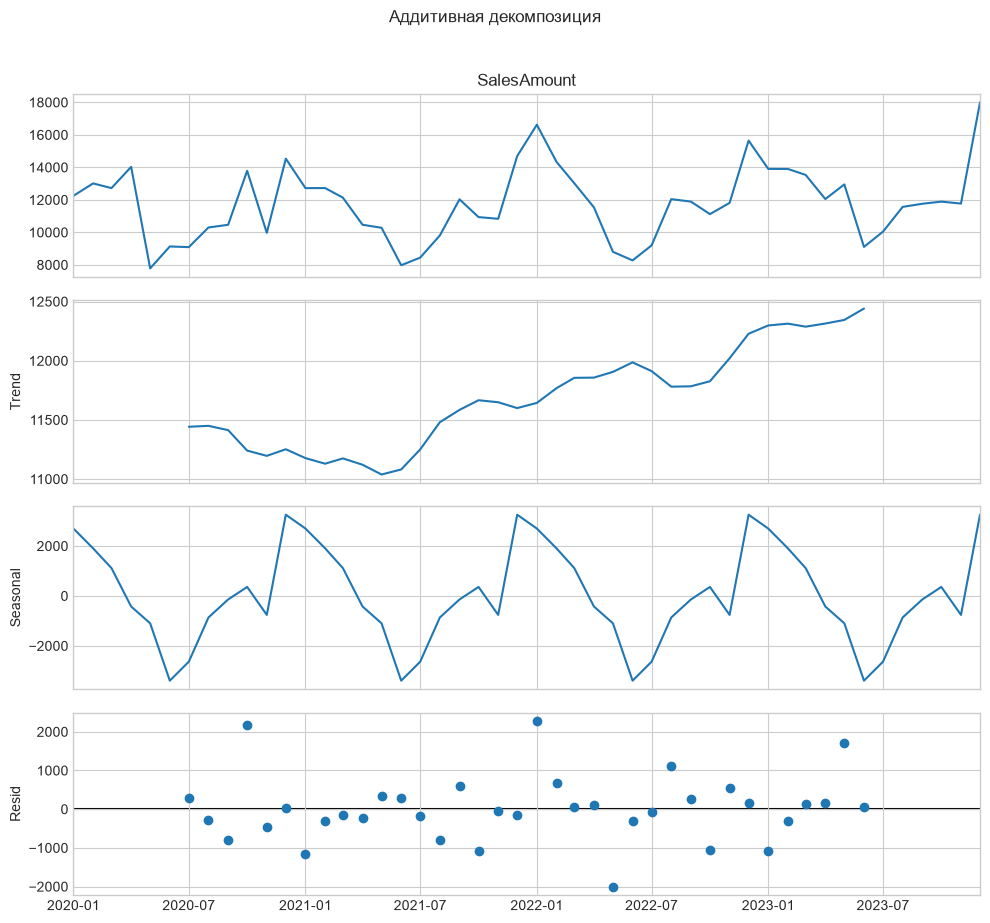

In [8]:
# аддитивная схема, сезон прибавкой в рублях
result_add = seasonal_decompose(y, model="additive", period=12)

fig = result_add.plot()
fig.set_size_inches((10, 9))
plt.suptitle("Аддитивная декомпозиция", y=1.02)
plt.tight_layout()
plt.show()


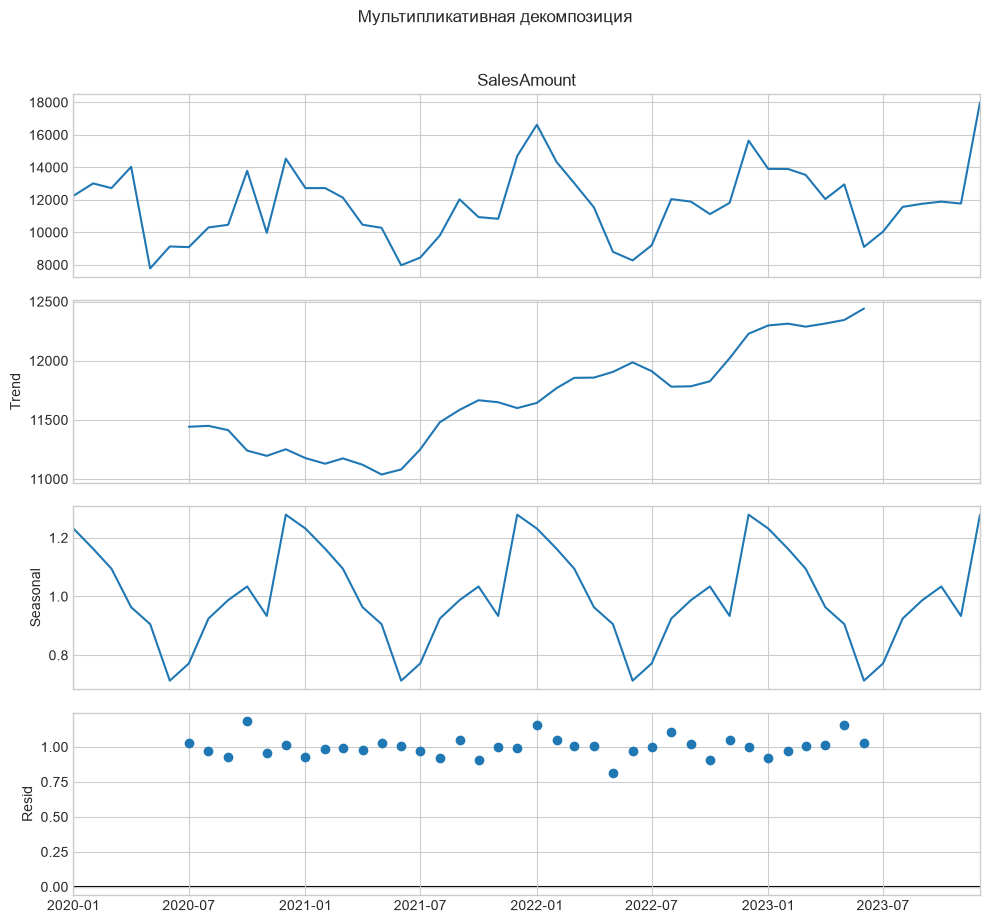

In [9]:
# мультипликативная схема, тот же сезон, но долей от уровня
# нулей в продажах нет, делить можно
result_mul = seasonal_decompose(y, model="multiplicative", period=12)

fig = result_mul.plot()
fig.set_size_inches((10, 9))
plt.suptitle("Мультипликативная декомпозиция", y=1.02)
plt.tight_layout()
plt.show()


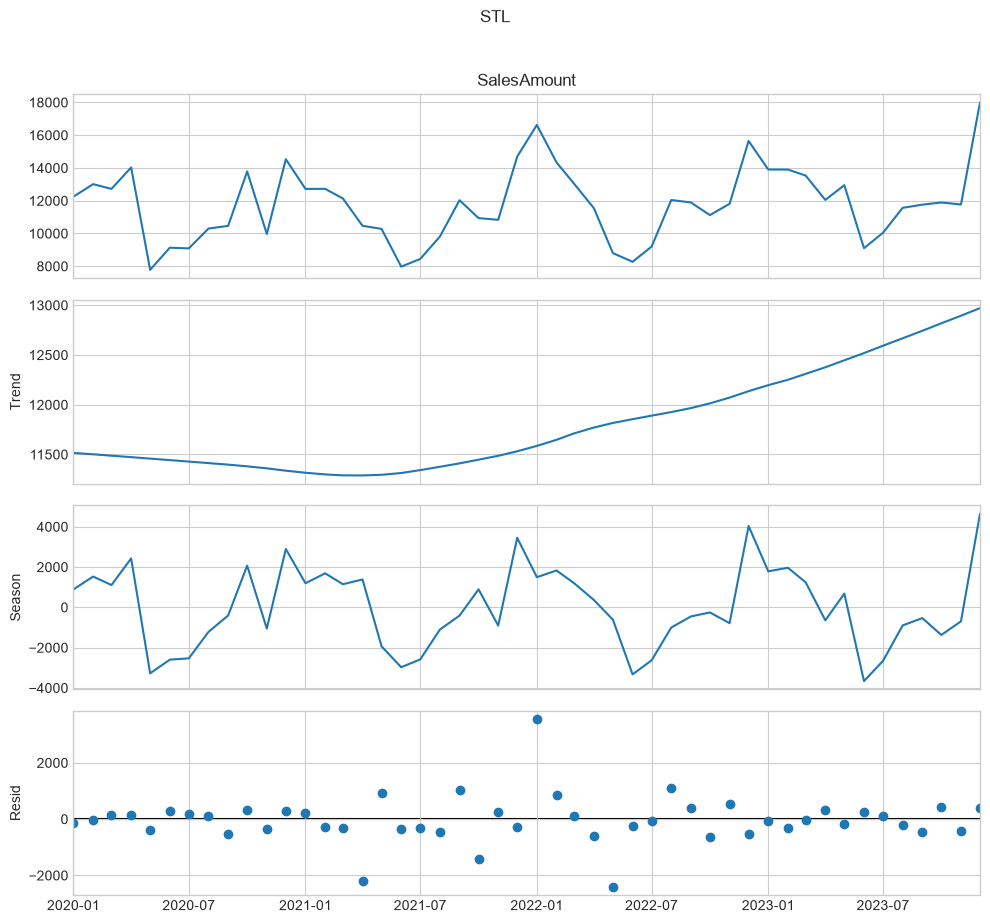

In [10]:
# окно 13 и robust=True из-за декабря, иначе один пик утащит тренд
stl = STL(y, period=12, seasonal=13, robust=True).fit()

fig = stl.plot()
fig.set_size_inches((10, 9))
plt.suptitle("STL", y=1.02)
plt.tight_layout()
plt.show()


In [11]:
# остатки аддитивной и мультипликативной модели в разных шкалах,
# сравниваем их уже в исходных продажах, насколько собранный ряд промахивается
fitted_add = (result_add.trend + result_add.seasonal).dropna()
fitted_mul = (result_mul.trend * result_mul.seasonal).dropna()
fitted_stl = stl.trend + stl.seasonal

rows = []
for name, fitted in [("аддитивная", fitted_add), ("мультипликативная", fitted_mul), ("STL", fitted_stl)]:
    actual = y.loc[fitted.index]
    err = actual - fitted
    rows.append({
        "метод": name,
        "MAE": err.abs().mean(),
        "MSE": mean_squared_error(actual, fitted),
    })

cmp = pd.DataFrame(rows).set_index("метод")
print(cmp.round(1))

print()
print("декабрь минус июнь и средний уровень по годам")
for year in range(2020, 2024):
    gap = float(y.loc[pd.Timestamp(year, 12, 1)] - y.loc[pd.Timestamp(year, 6, 1)])
    level = float(y[str(year)].mean())
    print(f"  {year}, размах {gap:.0f}, средний уровень года {level:.0f}")

print()
# не усредняем сразу, иначе не видно, повторяется профиль или нет
print("сезонная добавка аддитивной модели по годам")
season = result_add.seasonal
season_tbl = pd.DataFrame({
    "month": season.index.month,
    "year": season.index.year,
    "value": season.values,
})
print(season_tbl.pivot(index="month", columns="year", values="value").round(0))

                     MAE       MSE
метод                             
аддитивная         597.8  738430.7
мультипликативная  595.5  748125.7
STL                523.2  695699.1

декабрь минус июнь и средний уровень по годам
  2020, размах 5403, средний уровень года 11422
  2021, размах 6720, средний уровень года 11088
  2022, размах 7372, средний уровень года 12025
  2023, размах 8892, средний уровень года 12539

сезонная добавка аддитивной модели по годам
year     2020    2021    2022    2023
month                                
1      2698.0  2698.0  2698.0  2698.0
2      1905.0  1905.0  1905.0  1905.0
3      1113.0  1113.0  1113.0  1113.0
4      -425.0  -425.0  -425.0  -425.0
5     -1099.0 -1099.0 -1099.0 -1099.0
6     -3397.0 -3397.0 -3397.0 -3397.0
7     -2636.0 -2636.0 -2636.0 -2636.0
8      -865.0  -865.0  -865.0  -865.0
9      -144.0  -144.0  -144.0  -144.0
10      358.0   358.0   358.0   358.0
11     -762.0  -762.0  -762.0  -762.0
12     3253.0  3253.0  3253.0  3253.0


Аддитивная и мультипликативная схемы собирают ряд примерно одинаково, средняя абсолютная ошибка около 600. Мультипликативная не лучше, хотя уровень чуть растёт. Размах «декабрь минус июнь» идёт 5403, 6720, 7372, 8892, а средний уровень года за это время вырос примерно на 10%. Если бы сезон был просто долей от уровня, размах вырос бы тысяч до 6, а не до 9. Доля тоже не стоит на месте.

STL чуть ближе к ряду (MAE около 520), потому что сезонное окно скользит и амплитуда может меняться от года к году. На четырёх годах выигрыш небольшой. В таблице аддитивной добавки четыре столбца совпадают, схема так и устроена, один профиль на все годы. Декабрь около +3250, июнь около −3400. Лето вниз, декабрь вверх.


## Спектр, FFT

Фурье на ряде с трендом и с обрывом по краям размазывает пик. Сначала снимаем линейный тренд, потом окно Ханна.
Шаг ряда 1 месяц, так что частота в циклах за месяц, период в месяцах.


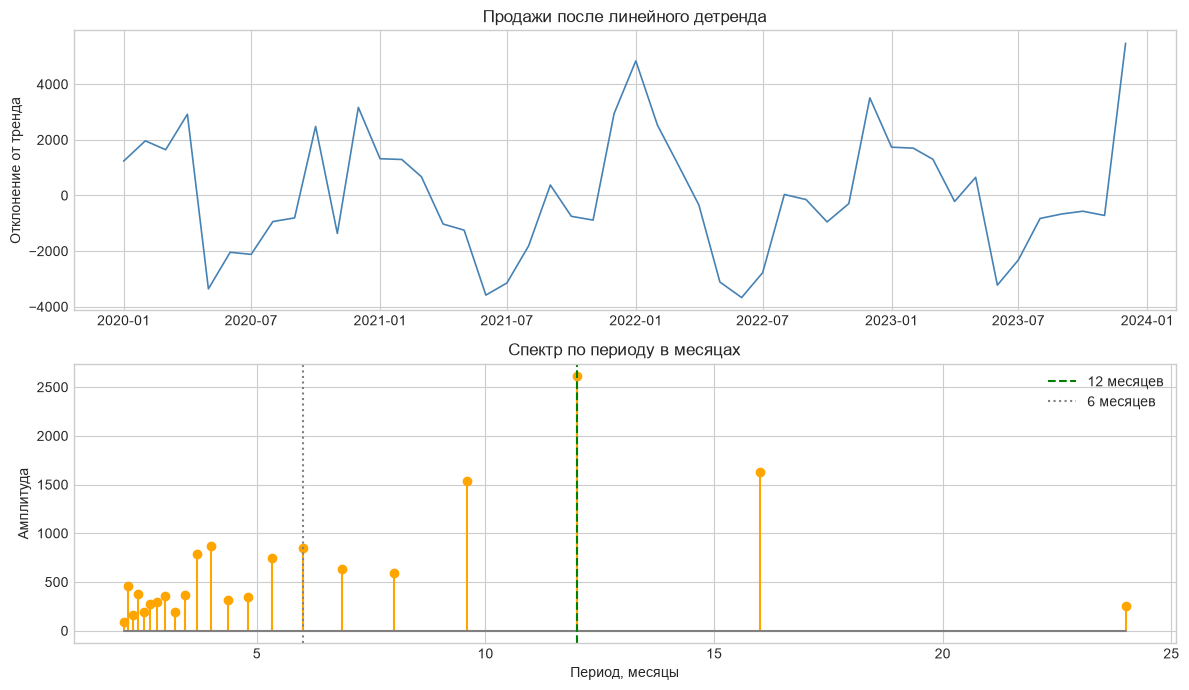

  период  амплитуда
   12.00     2610.3
   16.00     1623.9
    9.60     1531.8
    4.00      866.1
    6.00      851.4


In [12]:
sales = y.values.astype(float)
sales_dt = detrend(sales, type="linear")
window = windows.hann(len(sales_dt))
signal = sales_dt * window

n = len(signal)
fft_vals = fft(signal)
freqs = fftfreq(n, d=1)

# положительные частоты, амплитуда с поправкой на окно
power = np.abs(fft_vals[: n // 2]) * 2 / window.sum()
freqs_pos = freqs[: n // 2]
periods = 1 / freqs_pos[1:]
power_pos = power[1:]

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(y.index, sales_dt, color="steelblue", linewidth=1.2)
axes[0].set_title("Продажи после линейного детренда")
axes[0].set_ylabel("Отклонение от тренда")

mask = (periods >= 2) & (periods <= 24)
axes[1].stem(periods[mask], power_pos[mask], linefmt="orange", markerfmt="o", basefmt="gray")
axes[1].axvline(12, color="green", linestyle="--", label="12 месяцев")
axes[1].axvline(6, color="gray", linestyle=":", label="6 месяцев")
axes[1].set_title("Спектр по периоду в месяцах")
axes[1].set_xlabel("Период, месяцы")
axes[1].set_ylabel("Амплитуда")
axes[1].legend()

plt.tight_layout()
plt.show()


top_idx = np.argsort(power_pos)[::-1][:5]
print(f"{'период':>8} {'амплитуда':>10}")
for i in top_idx:
    print(f"{periods[i]:8.2f} {power_pos[i]:10.1f}")


Главный пик ровно на 12 месяцах. В 48 отсчётах туда попадает целый бин, 4 цикла за 4 года, утечки из-за нецелого числа периодов нет. Следующие по высоте 16 и 9.6 месяца. Это соседние бины (3/48 и 5/48), энергия годового цикла чуть расплескалась, отдельных циклов там нет. Период 6 месяцев слабее, его и так видно. Внутри года два горба, зима и всё остальное.

Спектр один на весь ряд. Стал ли годовой цикл сильнее к 2023, отсюда не прочитать.


## Вейвлет Морле

Считаем непрерывное преобразование с Морле. Период на оси в месяцах.

Добеши не берём. У дискретного разложения шкалы идут октавами, 2, 4, 8, 16 месяцев, период около года оказался бы между 8 и 16.

Линейный тренд снимаем до преобразования, чтобы он не смешался с циклом на длинных масштабах.


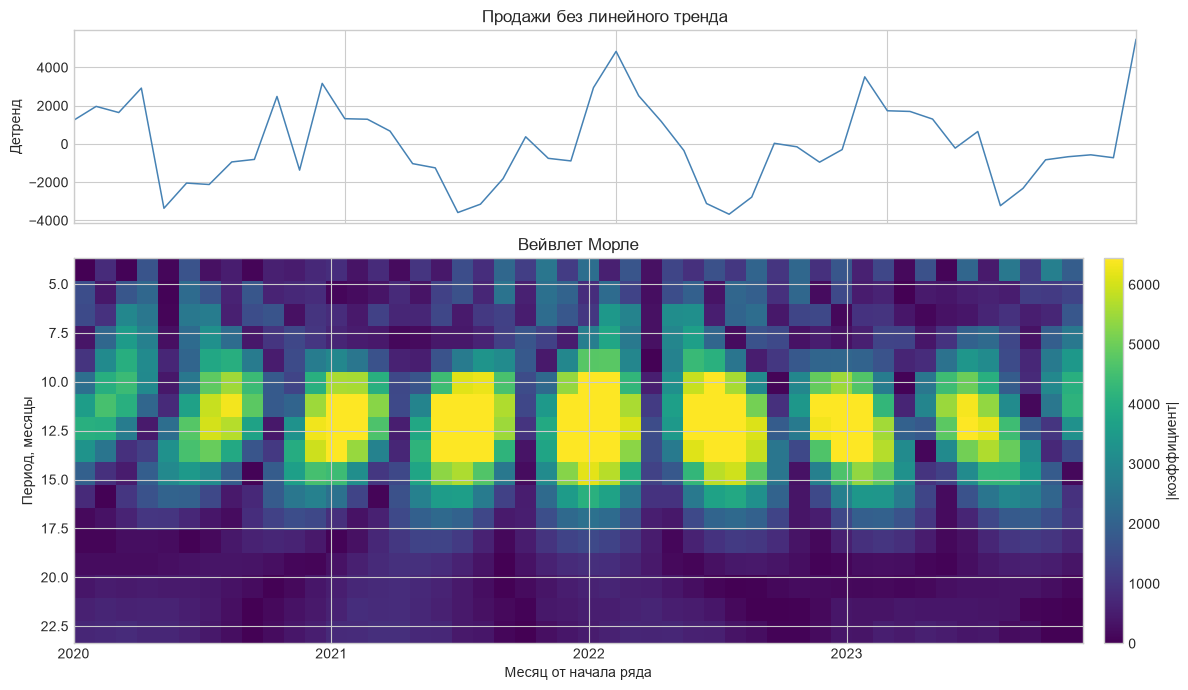

сильные периоды, среднее по времени
   12.3 мес., средняя сила 4939
    9.8 мес., средняя сила 3698
   14.8 мес., средняя сила 3131
    7.4 мес., средняя сила 1380


In [13]:
scales = np.arange(1, 32)
coef, frequencies = pywt.cwt(sales_dt, scales, "morl", sampling_period=1)
periods_w = 1 / frequencies
power_w = np.abs(coef)

# короче 3 месяцев и длиннее 2 лет на 48 точках не читаем
# снизу шум, сверху край ряда
band = (periods_w >= 3) & (periods_w <= 24)
periods_plot = periods_w[band]
power_plot = power_w[band, :]

t = np.arange(len(sales_dt))

fig, axes = plt.subplots(
    2, 1, figsize=(12, 7), sharex=True,
    gridspec_kw={"height_ratios": [1, 2]},
)

axes[0].plot(t, sales_dt, color="steelblue", linewidth=1.1)
axes[0].set_ylabel("Детренд")
axes[0].set_title("Продажи без линейного тренда")

im = axes[1].imshow(
    power_plot,
    extent=[t.min(), t.max(), periods_plot.max(), periods_plot.min()],
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=np.percentile(power_plot, 95),
)
axes[1].set_ylabel("Период, месяцы")
axes[1].set_xlabel("Месяц от начала ряда")
axes[1].set_title("Вейвлет Морле")
axes[1].set_xticks([0, 12, 24, 36])
axes[1].set_xticklabels(["2020", "2021", "2022", "2023"])
fig.colorbar(im, ax=axes[1], fraction=0.03, pad=0.02, label="|коэффициент|")

plt.tight_layout()
plt.show()

mean_power = power_plot.mean(axis=1)
order = np.argsort(mean_power)[::-1]
print("сильные периоды, среднее по времени")
seen = []
for i in order:
    period = periods_plot[i]
    if any(abs(period - old) < 1.5 for old in seen):
        continue
    seen.append(period)
    print(f"  {period:5.1f} мес., средняя сила {mean_power[i]:.0f}")
    if len(seen) == 4:
        break

ближайший к 12 месяцам период 12.31


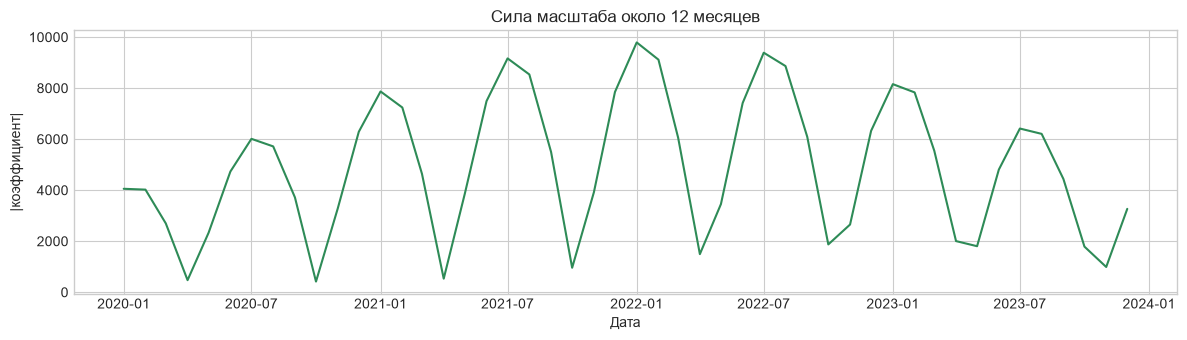

средняя сила этого масштаба по годам
  2020 3645
  2021 5629
  2022 6044
  2023 4437


In [14]:
# шкала, ближе всего к году, и как её сила меняется
idx_year = np.argmin(np.abs(periods_w - 12))
power_year = power_w[idx_year]
print(f"ближайший к 12 месяцам период {periods_w[idx_year]:.2f}")

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(y.index, power_year, color="seagreen", linewidth=1.5)
ax.set_title("Сила масштаба около 12 месяцев")
ax.set_ylabel("|коэффициент|")
ax.set_xlabel("Дата")
plt.tight_layout()
plt.show()

print("средняя сила этого масштаба по годам")
for year in range(2020, 2024):
    sl = power_year[(y.index.year == year)]
    print(f"  {year} {sl.mean():.0f}")

**Вывод по трём разложениям.** Период у всех один - год. Расходятся они в том, можно ли считать этот сезон постоянным.

Аддитивная и мультипликативная декомпозиция рисуют один профиль на все четыре года. Для картинки хватает, средняя ошибка около 600. Мультипликативную в модель не берём. Размах «декабрь минус июнь» вырос с 5403 до 8892, а уровень года примерно на 10%. Доля от уровня так не растёт. И по остатку классики не видно, в каком году цикл был сильнее.

STL ближе к ряду, ошибка около 520, окно скользит, декабрь может раздуваться. На четырёх годах это всего ~70 единиц к классике. Краям тренда меньше верим, STL их достраивает.

FFT здесь полезен другим. Период 12 мы ему не задавали, пик сам туда встал и отделился от соседних бинов 9.6 и 16. Спектр при этом один на весь кусок, 2020 и 2023 для него одинаковые.

Вейвлет показывает, когда цикл сильный. Масштаб около года есть всегда, к 2022 он выше, чем в 2020. Периоды длиннее двух лет на 48 точках не читаем, там край ряда. В модель отсюда уходит s=12 и ещё одно. Форма сезона та же, но декабрь ползёт вверх, одной разности с лагом 12 мало, нужен небольшой сдвиг уровня.


## Модели

В тест берём последний год, 12 месяцев 2023. Режем по времени, без перемешивания, иначе будущее окажется в обучении.

ARIMA подбираем по тому, что уже посчитали. `d=0`, ADF и KPSS не просят разность. Для короткой части берём `p=1`, на PACF лаг 2 близок к нулю. Лаг 12 при этом остаётся, его в обычную ARIMA не закладываем. Рядом посчитаем соседние порядки и варианты с `d=1`. Что из этого лучше на 2023, смотрим по прогнозу, не только по AIC.

Для SARIMAX период 12. После сезонной разности смотрим, осталась ли короткая память. Экзогенная переменная `Promotion`. `HolidayMonth` проверим отдельно, не повторяет ли он сезонный лаг.


train с 2020-01-01 по 2022-12-01, n=36
test с 2023-01-01 по 2023-12-01, n=12


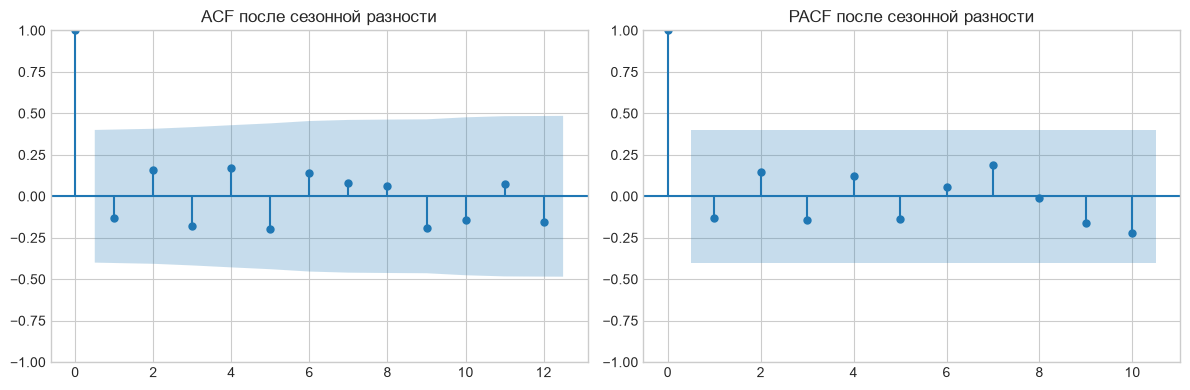

In [15]:
HORIZON = 12
train = y.iloc[:-HORIZON]
test = y.iloc[-HORIZON:]
promo = df[["Promotion"]].astype(float)

print(f"train с {train.index.min().date()} по {train.index.max().date()}, n={len(train)}")
print(f"test с {test.index.min().date()} по {test.index.max().date()}, n={len(test)}")

# сезонная разность обучающего куска, осталась ли структура для p и q
sdiff = train.diff(12).dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(sdiff, lags=12, ax=axes[0], title="ACF после сезонной разности")
plot_pacf(sdiff, lags=10, ax=axes[1], title="PACF после сезонной разности", method="ywm")
plt.tight_layout()
plt.show()

In [16]:
# короткая сетка, не все порядки подряд, а то, что следует из графиков
orders = [(1, 0, 0), (1, 0, 1), (2, 0, 0), (0, 1, 1), (1, 1, 1)]

arima_rows = []
for order in orders:
    model = ARIMA(train, order=order).fit()
    pred = model.forecast(HORIZON)
    arima_rows.append({
        "order": str(order),
        "AIC": model.aic,
        "BIC": model.bic,
        "MSE": mean_squared_error(test, pred),
        "R2": r2_score(test, pred),
    })

arima_table = pd.DataFrame(arima_rows).set_index("order")
print(arima_table.round(2))


              AIC     BIC          MSE    R2
order                                       
(1, 0, 0)  653.07  657.82   4733414.56 -0.02
(1, 0, 1)  655.15  661.48   4746199.60 -0.03
(2, 0, 0)  655.08  661.41   4760068.36 -0.03
(0, 1, 1)  642.35  645.46  11825852.83 -1.56
(1, 1, 1)  643.80  648.47  12562628.26 -1.72


По AIC среди ARIMA лучшие модели с `d=1`, но их R² на 2023 отрицательный. Разность превращает прогноз в «последнее значение плюс шум», и год вперёд это не живёт. AR(1) тоже не попадает в сезон (R² около нуля), зато это ровно та модель, которую просят тесты и PACF. Её и оставляем как ARIMA. Выше качеством она от сезонной модели не станет, и это как раз аргумент, а не повод подгонять порядок под тест.


In [17]:
# разность с лагом 12 у праздника и у акции
holiday_sdiff = df["HolidayMonth"].diff(12).dropna()
promo_sdiff = df["Promotion"].diff(12).dropna()
print("праздник, сумма модулей сезонной разности", float(holiday_sdiff.abs().sum()))
print("акция, сумма модулей сезонной разности", float(promo_sdiff.abs().sum()))


праздник, сумма модулей сезонной разности 0.0
акция, сумма модулей сезонной разности 8.0


У праздника сумма модулей равна 0. После разности с лагом 12 от него ничего не остаётся, в SARIMAX его не кладём. У акции сумма 8, флаг от года к году меняется, его оставляем.


In [18]:
# константа в сезонной разности, сдвиг того же месяца к следующему году
specs = [
    ((0, 0, 0), (0, 1, 0, 12)),
    ((1, 0, 0), (0, 1, 0, 12)),
    ((0, 0, 0), (0, 1, 1, 12)),
    ((1, 0, 1), (0, 1, 1, 12)),
    ((0, 1, 1), (0, 1, 1, 12)),
    ((1, 0, 0), (1, 0, 0, 12)),
]

sx_rows = []
fitted_sx = {}
for order, seasonal in specs:
    model = SARIMAX(
        train,
        exog=promo.loc[train.index],
        order=order,
        seasonal_order=seasonal,
        trend="c",
    ).fit(disp=False)
    pred = model.get_forecast(HORIZON, exog=promo.loc[test.index]).predicted_mean
    name = f"{order}x{seasonal}"
    fitted_sx[name] = model
    sx_rows.append({
        "model": name,
        "AIC": model.aic,
        "BIC": model.bic,
        "MSE": mean_squared_error(test, pred),
        "R2": r2_score(test, pred),
    })

sx_table = pd.DataFrame(sx_rows).set_index("model")
print(sx_table.round(2))
print()


                            AIC     BIC          MSE    R2
model                                                     
(0, 0, 0)x(0, 1, 0, 12)  396.07  399.60    606056.30  0.87
(1, 0, 0)x(0, 1, 0, 12)  398.04  402.75    609425.71  0.87
(0, 0, 0)x(0, 1, 1, 12)  393.76  398.47    624030.04  0.87
(1, 0, 1)x(0, 1, 1, 12)  390.93  398.00    793986.75  0.83
(0, 1, 1)x(0, 1, 1, 12)  390.54  396.21    957535.37  0.79
(1, 0, 0)x(1, 0, 0, 12)  715.65  723.57  16799849.98 -2.63



In [19]:
# в таблице выше у модели с AR и MA AIC меньше, смотрим коэффициенты
rich_name = "(1, 0, 1)x(0, 1, 1, 12)"
print(rich_name)
print(fitted_sx[rich_name].summary().tables[1])
print()
print("(0, 0, 0)x(0, 1, 1, 12)")
print(fitted_sx["(0, 0, 0)x(0, 1, 1, 12)"].summary().tables[1])


(1, 0, 1)x(0, 1, 1, 12)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    482.9265   2.72e+04      0.018      0.986   -5.28e+04    5.38e+04
Promotion   2591.9129    335.700      7.721      0.000    1933.953    3249.873
ar.L1          0.5062     27.797      0.018      0.985     -53.975      54.988
ma.L1         -0.5085     27.707     -0.018      0.985     -54.813      53.796
ma.S.L12      -0.3519      0.180     -1.952      0.051      -0.705       0.001
sigma2      3.819e+05   1.87e+05      2.047      0.041    1.63e+04    7.47e+05

(0, 0, 0)x(0, 1, 1, 12)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    516.0417    283.384      1.821      0.069     -39.381    1071.465
Promotion   2574.0000    403.119      6.385      0.000    1783.901    3364.099
ma.

Берём `SARIMAX(0, 0, 0)(0, 1, 0, 12)` с константой и `Promotion`.

Почему не модель с меньшим AIC. У `(1, 0, 1)(0, 1, 1, 12)` AIC ниже, но AR и MA стоят друг напротив друга (плюс 0.5 и минус 0.5) со стандартной ошибкой около 28. Константа при этом тоже разъезжается, p почти 1. Параметры не идентифицируются, на тесте R² хуже (0.83 против 0.87).

У варианта только с сезонным MA, `(0, 0, 0)(0, 1, 1, 12)`, AIC 394 против 396, BIC тоже лучше примерно на единицу. Сам `ma.S` около −0.11 и p=0.32. На 2023 год R² тот же. Единица AIC за незначимый коэффициент не повод усложнять, на 24 точках после разности сезонный MA всё равно толком не оценить.

Обычную разность не добавляем, ADF её не просил, airline на тесте слабее. Модель без сезонной разности, только с сезонным AR, на 2023 разваливается, R² отрицательный.

AIC между `d=0` и `d=1` в лоб не сравниваем, правдоподобие считается после разного числа разностей.


In [20]:
# обучаем выбранные выше AR(1) и SARIMAX с сезонной разностью, константой и акцией
model_arima = ARIMA(train, order=(1, 0, 0)).fit()
model_sx = SARIMAX(
    train,
    exog=promo.loc[train.index],
    order=(0, 0, 0),
    seasonal_order=(0, 1, 0, 12),
    trend="c",
).fit(disp=False)

print(model_arima.summary())
print(model_sx.summary())


                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   36
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -323.535
Date:                Sat, 26 Sep 2026   AIC                            653.070
Time:                        17:21:19   BIC                            657.821
Sample:                    01-01-2020   HQIC                           654.728
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.151e+04    669.394     17.197      0.000    1.02e+04    1.28e+04
ar.L1          0.4941      0.190      2.601      0.009       0.122       0.866
sigma2       3.81e+06   9.21e+05      4.136      0.0

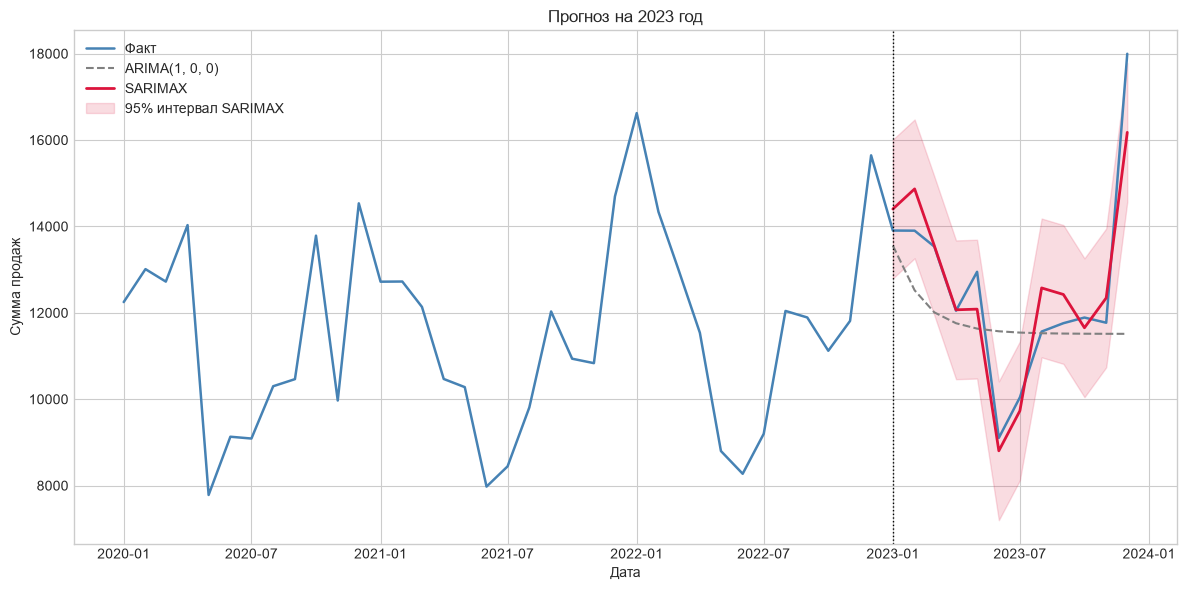

               факт  SARIMAX    ARIMA  тот же месяц год назад  акция
2023-01-01  13904.0  14403.0  13554.0                 16623.0    0.0
2023-02-01  13901.0  14868.0  12521.0                 14336.0    0.0
2023-03-01  13534.0  13555.0  12010.0                 13023.0    0.0
2023-04-01  12048.0  12069.0  11758.0                 11537.0    0.0
2023-05-01  12949.0  12085.0  11634.0                  8800.0    1.0
2023-06-01   9104.0   8805.0  11572.0                  8273.0    0.0
2023-07-01  10042.0   9731.0  11542.0                  9199.0    0.0
2023-08-01  11566.0  12575.0  11527.0                 12043.0    0.0
2023-09-01  11759.0  12424.0  11519.0                 11892.0    0.0
2023-10-01  11890.0  11653.0  11515.0                 11121.0    0.0
2023-11-01  11770.0  12344.0  11514.0                 11812.0    0.0
2023-12-01  17996.0  16177.0  11513.0                 15645.0    0.0
вне 95% интервала ['2023-12']


In [21]:
fc_ar = model_arima.get_forecast(HORIZON)
fc_sx = model_sx.get_forecast(HORIZON, exog=promo.loc[test.index])
pred_ar = fc_ar.predicted_mean
pred_sx = fc_sx.predicted_mean
ci_sx = fc_sx.conf_int()

naive = y.shift(12).iloc[-HORIZON:]

plt.figure(figsize=(12, 6))
sns.lineplot(x=y.index, y=y.values, label="Факт", color="steelblue", linewidth=1.8)
# серым рисуем прогноз ARIMA
sns.lineplot(x=pred_ar.index, y=pred_ar.values, label="ARIMA(1, 0, 0)", color="gray", linestyle="--")
sns.lineplot(x=pred_sx.index, y=pred_sx.values, label="SARIMAX", color="crimson", linewidth=2)
plt.fill_between(
    ci_sx.index,
    ci_sx.iloc[:, 0],
    ci_sx.iloc[:, 1],
    color="crimson",
    alpha=0.15,
    label="95% интервал SARIMAX",
)
# граница теста, дальше 2023
plt.axvline(test.index[0], color="black", linestyle=":", linewidth=1)
plt.title("Прогноз на 2023 год")
plt.xlabel("Дата")
plt.ylabel("Сумма продаж")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# наивный лаг 12 оставляем в таблице, на графике и так факт, две модели и интервал
check = pd.DataFrame({
    "факт": test,
    "SARIMAX": pred_sx,
    "ARIMA": pred_ar,
    "тот же месяц год назад": naive,
    "акция": promo.loc[test.index, "Promotion"],
})
print(check.round(0))
outside = (test.values < ci_sx.iloc[:, 0].values) | (test.values > ci_sx.iloc[:, 1].values)
print("вне 95% интервала", test.index[outside].strftime("%Y-%m").tolist())


AR(1) после пары месяцев выходит на среднее около 11.5 тысяч и дальше рисует почти прямую. Лето и декабрь он не видит.

SARIMAX повторяет прошлый год, плюс константа около +530 (тот же месяц стал чуть выше), и поправляет акцию. Январь 2022 был с акцией, январь 2023 без неё, модель снимает примерно 2750 и попадает в 13904 (прогноз около 14400). Май 2023 с акцией, май 2022 без, модель добавляет те же 2750 к низкой базе и даёт около 12100 при факте 12949. Недобор есть, акция в мае 2023 сработала сильнее средней. Декабрь 16177 против 17996, пик вырос быстрее, чем постоянный сдвиг. Это как раз то, что на вейвлете и в размахе «декабрь минус июнь» уже было видно. Декабрь один вылезает за 95% интервал, остальные месяцы 2023 внутри.


In [22]:
# горизонты 6, 12, 18 и 24 месяца
# длиннее не берём, после лага 12 в обучении должен остаться ещё один год
horizon_rows = []
for h in [6, 12, 18, 24]:
    tr = y.iloc[:-h]
    te = y.iloc[-h:]
    ex_tr = promo.loc[tr.index]
    ex_te = promo.loc[te.index]

    sx = SARIMAX(
        tr, exog=ex_tr, order=(0, 0, 0), seasonal_order=(0, 1, 0, 12), trend="c",
    ).fit(disp=False)
    ar = ARIMA(tr, order=(1, 0, 0)).fit()
    pred_s = sx.get_forecast(h, exog=ex_te).predicted_mean
    pred_a = ar.forecast(h)
    pred_n = y.shift(12).iloc[-h:]

    horizon_rows.append({
        "горизонт": h,
        "R2 SARIMAX": r2_score(te, pred_s),
        "MSE SARIMAX": mean_squared_error(te, pred_s),
        "R2 ARIMA": r2_score(te, pred_a),
        "R2 наивный сезон": r2_score(te, pred_n),
        "константа": sx.params["intercept"],
        "p константы": sx.pvalues["intercept"],
    })

horizon_table = pd.DataFrame(horizon_rows).set_index("горизонт")
print(horizon_table.round(3))


          R2 SARIMAX  MSE SARIMAX  R2 ARIMA  R2 наивный сезон  константа  \
горизонт                                                                   
6              0.864   875242.036    -0.073             0.817    531.919   
12             0.869   606056.300    -0.023             0.404    532.144   
18             0.810   832570.962    -0.170             0.485    431.806   
24             0.682  1737576.896    -0.100             0.523     85.000   

          p константы  
горизонт               
6               0.000  
12              0.003  
18              0.039  
24              0.813  


**Вывод по моделям.** Рабочий горизонт 12 месяцев, R² около 0.87. На 18 месяцах ещё 0.81, константа значима. На 24 месяцах обучение это 2020 и 2021, роста там почти нет, константа становится около нуля и незначимой, R² падает до 0.68. Формально это всё ещё выше наивного «тот же месяц год назад» (0.52), но дрейф уже не оценивается, и план на два года по этому ряду ставить не будем. Дальше 24 месяцев проверить не на чем, ряд сам длиной 48.

Приемлемым считаем горизонт, где R² держится выше 0.75 и константа ещё оценивается. Это 18 месяцев, не больше. ARIMA на любом из этих горизонтов остаётся около нуля или ниже, без сезона ей не за что зацепиться.


## Качество

MSE и R² считаем на одном и том же тесте, 2023 год. AIC и BIC считаем по обучающей выборке, это не про тест, а про то, насколько модель описывает то, на чём её учили. Наивный прогноз «как в том же месяце год назад» кладём в таблицу линейкой, иначе R² не с чем сравнить.


In [23]:
# у наивного нет AIC и BIC, это не оценённая модель, а продажи с лагом 12
metrics = pd.DataFrame([
    {
        "модель": "ARIMA(1, 0, 0)",
        "MSE": mean_squared_error(test, pred_ar),
        "R2": r2_score(test, pred_ar),
        "AIC": model_arima.aic,
        "BIC": model_arima.bic,
    },
    {
        "модель": "наивный, лаг 12",
        "MSE": mean_squared_error(test, naive),
        "R2": r2_score(test, naive),
        "AIC": np.nan,
        "BIC": np.nan,
    },
    {
        "модель": "SARIMAX(0,0,0)(0,1,0,12) + акция",
        "MSE": mean_squared_error(test, pred_sx),
        "R2": r2_score(test, pred_sx),
        "AIC": model_sx.aic,
        "BIC": model_sx.bic,
    },
])
print(metrics.round(2).to_string(index=False))
print()
print(f"RMSE SARIMAX {mean_squared_error(test, pred_sx) ** 0.5:.0f}")
print(f"RMSE ARIMA {mean_squared_error(test, pred_ar) ** 0.5:.0f}")


                          модель        MSE    R2    AIC    BIC
                  ARIMA(1, 0, 0) 4733414.56 -0.02 653.07 657.82
                 наивный, лаг 12 2757115.25  0.40    NaN    NaN
SARIMAX(0,0,0)(0,1,0,12) + акция  606056.30  0.87 396.07 399.60

RMSE SARIMAX 778
RMSE ARIMA 2176


## Остатки

Нормальность проверяем через Jarque-Bera и Q-Q. Автокорреляцию через Дарбин-Уотсон и Льюнг-Бокс. DW в основном смотрит на лаг 1, а у этого ряда проблема была на лаге 12, поэтому одного DW мало. Гомоскедастичность смотрим по Бройш-Пагану, остатки против подогнанных значений, плюс само облако остатков.

Остатки SARIMAX берём после первого сезонного года. Первые 12 значений сезонной разности ещё не остатки модели.


In [ ]:
# у AR(1) первый остаток пустой, ему не на что опереться
resid_ar = model_arima.resid.iloc[1:]
# первый год SARIMAX это ещё не остаток, сезонная разность начинается со второго
resid_sx = model_sx.resid.iloc[12:]
fitted_sx = model_sx.fittedvalues.iloc[12:]

def residual_tests(resid, fitted, name):
    jb_stat, jb_p, _, _ = jarque_bera(resid)
    dw = durbin_watson(resid)
    # лаг 1 и лаг 12 отдельно, DW год не видит
    lb = acorr_ljungbox(resid, lags=[1, 12], return_df=True)
    bp = het_breuschpagan(resid.loc[fitted.index], sm.add_constant(fitted))
    print(name)
    print(f"  Jarque-Bera p-value: {jb_p:.3f}")
    print(f"  Durbin-Watson: {dw:.3f}")
    print(f"  Ljung-Box p, лаг 1: {lb.loc[1, 'lb_pvalue']:.3f}")
    print(f"  Ljung-Box p, лаг 12: {lb.loc[12, 'lb_pvalue']:.3f}")
    print(f"  Breusch-Pagan p: {bp[1]:.3f}")
    print()

residual_tests(resid_ar, model_arima.fittedvalues.iloc[1:], "ARIMA(1, 0, 0)")
residual_tests(resid_sx, fitted_sx, "SARIMAX")


ARIMA(1, 0, 0)
  Jarque-Bera p-value: 0.920
  Durbin-Watson: 1.834
  Ljung-Box p, лаг 1: 0.903
  Ljung-Box p, лаг 12: 0.027
  Breusch-Pagan p: 0.360

SARIMAX
  Jarque-Bera p-value: 0.610
  Durbin-Watson: 1.830
  Ljung-Box p, лаг 1: 0.679
  Ljung-Box p, лаг 12: 0.411
  Breusch-Pagan p: 0.385



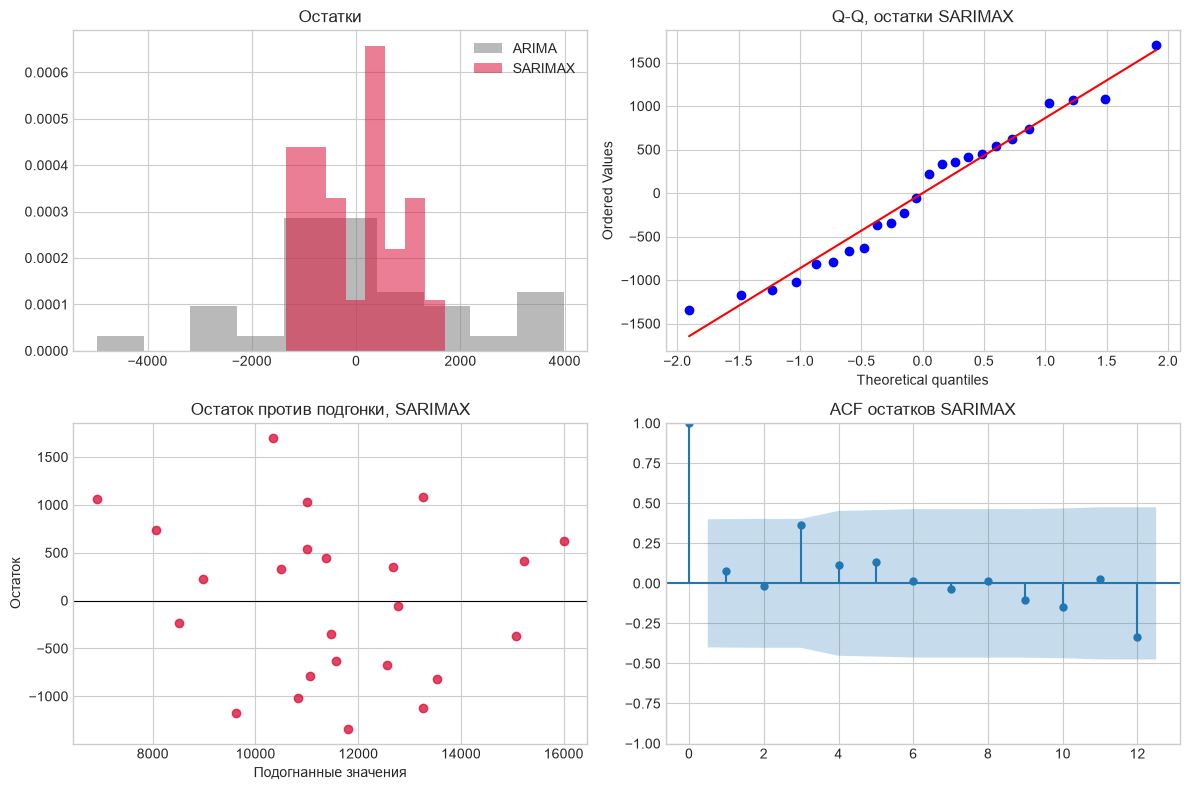

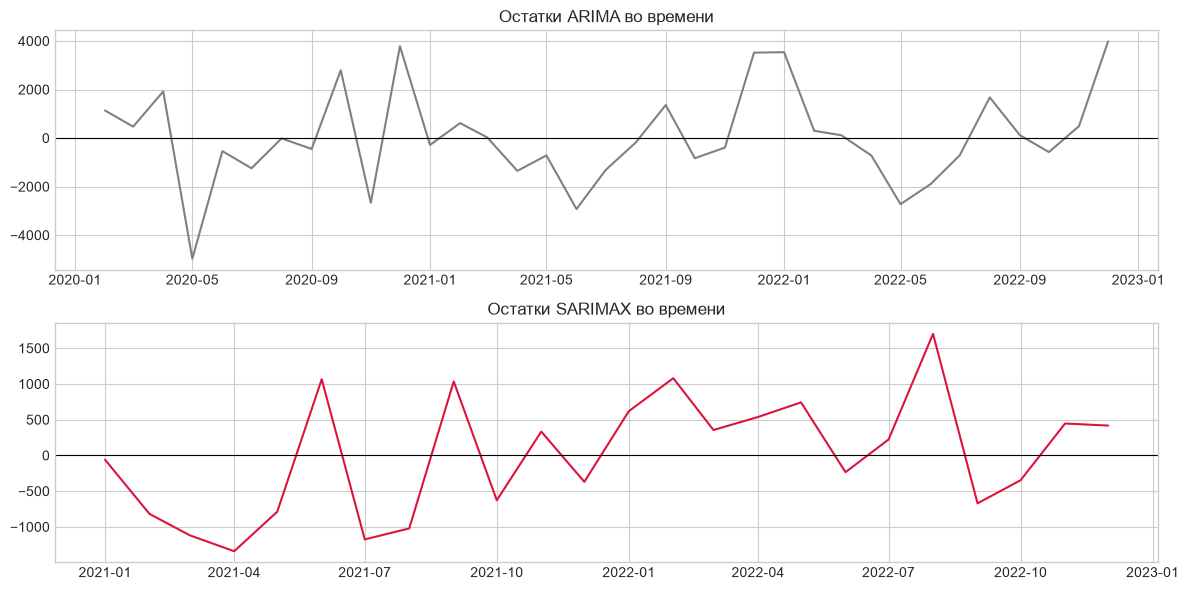

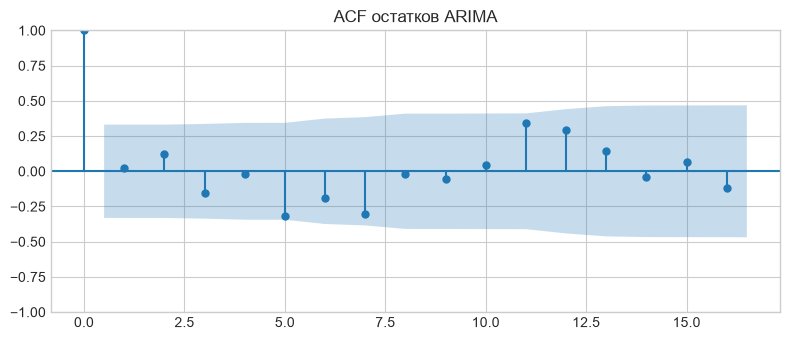

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(resid_ar, bins=10, alpha=0.55, color="gray", label="ARIMA", density=True)
axes[0, 0].hist(resid_sx, bins=8, alpha=0.55, color="crimson", label="SARIMAX", density=True)
axes[0, 0].set_title("Остатки")
axes[0, 0].legend()

# Q-Q и облако только у SARIMAX, её и проверяем как рабочую модель
stats.probplot(resid_sx, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Q-Q, остатки SARIMAX")

axes[1, 0].scatter(fitted_sx, resid_sx, color="crimson", alpha=0.8)
axes[1, 0].axhline(0, color="black", linewidth=0.8)
axes[1, 0].set_xlabel("Подогнанные значения")
axes[1, 0].set_ylabel("Остаток")
axes[1, 0].set_title("Остаток против подгонки, SARIMAX")

plot_acf(resid_sx, lags=12, ax=axes[1, 1], title="ACF остатков SARIMAX")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
axes[0].plot(resid_ar.index, resid_ar.values, color="gray")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Остатки ARIMA во времени")
axes[1].plot(resid_sx.index, resid_sx.values, color="crimson")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Остатки SARIMAX во времени")
plt.tight_layout()
plt.show()

# ACF остатков ARIMA, смотрим лаг 12
fig = plot_acf(resid_ar, lags=16, title="ACF остатков ARIMA")
fig.set_size_inches(8, 3.5)
plt.tight_layout()
plt.show()


**Вывод по качеству.** На 2023 год SARIMAX даёт MSE около 606 тысяч (RMSE около 780) и R² 0.87. Наивный повтор прошлого года даёт MSE около 2.76 миллиона, R² 0.40. ARIMA(1, 0, 0) даёт MSE около 4.73 миллиона, R² −0.02, то есть хуже, чем просто среднее теста. AIC и BIC в таблице лежат рядом, но ARIMA и SARIMAX по ним не ранжируем, у сезонной разности правдоподобие считается уже по другому ряду. Внутри одной схемы разностей AIC использовали раньше, при отборе. Между семействами смотрим тест, MSE и R².

Остатки SARIMAX на нормальность не ругаются (Jarque-Bera p около 0.61), Льюнг-Бокс на лаге 12 спокойный (p около 0.41), Дарбин-Уотсон около 1.83, Бройш-Паган p около 0.38. Облако остатков против подгонки без воронки. У ARIMA нормальность и дисперсия тоже в порядке, а автокорреляция на лаге 12 нет, сезон так и остался в остатках. Поэтому ARIMA и промахивается летом и в декабре.

Предпочтительная модель это SARIMAX. Не из-за того, что у неё больше параметров, их как раз два содержательных, годовой сдвиг около +530 и акция около +2750. А из-за того, что она попадает в форму года, а ARIMA нет.
